# Customer Churn EDA
Exploratory Data Analysis on IBM Telco Customer Churn dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

df = pd.read_csv('../data/churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Basic info
print('Columns:', df.columns.tolist())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 customerID          0
gender     

In [3]:
# Fix TotalCharges — stored as string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing after fix:', df['TotalCharges'].isnull().sum())
df.dropna(inplace=True)
print('Final shape:', df.shape)

Missing after fix: 11
Final shape: (7032, 21)


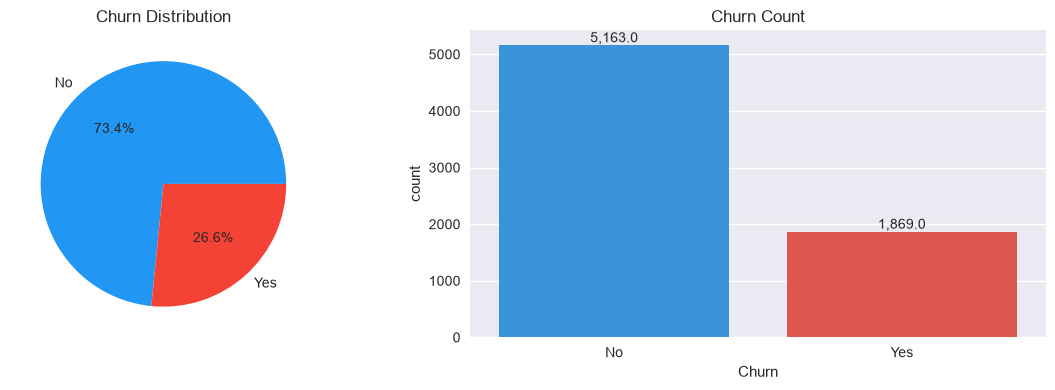

Churn rate: 26.6 %


In [4]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#2196F3','#F44336'])
axes[0].set_title('Churn Distribution')

sns.countplot(data=df, x='Churn', ax=axes[1], palette=['#2196F3','#F44336'])
axes[1].set_title('Churn Count')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,}', (p.get_x()+p.get_width()/2, p.get_height()+50), ha='center')

plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Churn rate:', round(churn_counts['Yes']/len(df)*100, 1), '%')

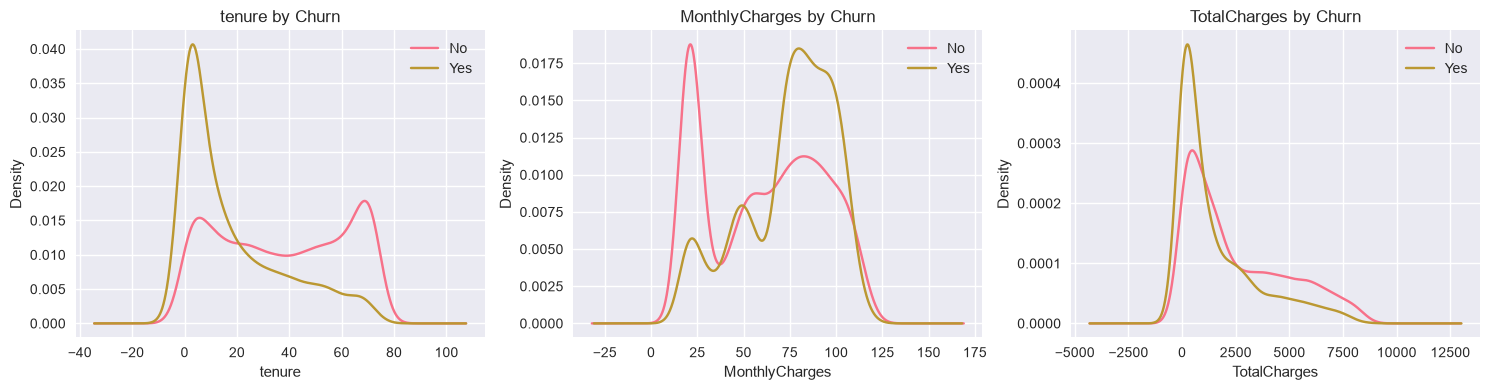

In [5]:
# Numerical features vs churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    df.groupby('Churn')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('../data/numerical_features.png', dpi=150, bbox_inches='tight')
plt.show()

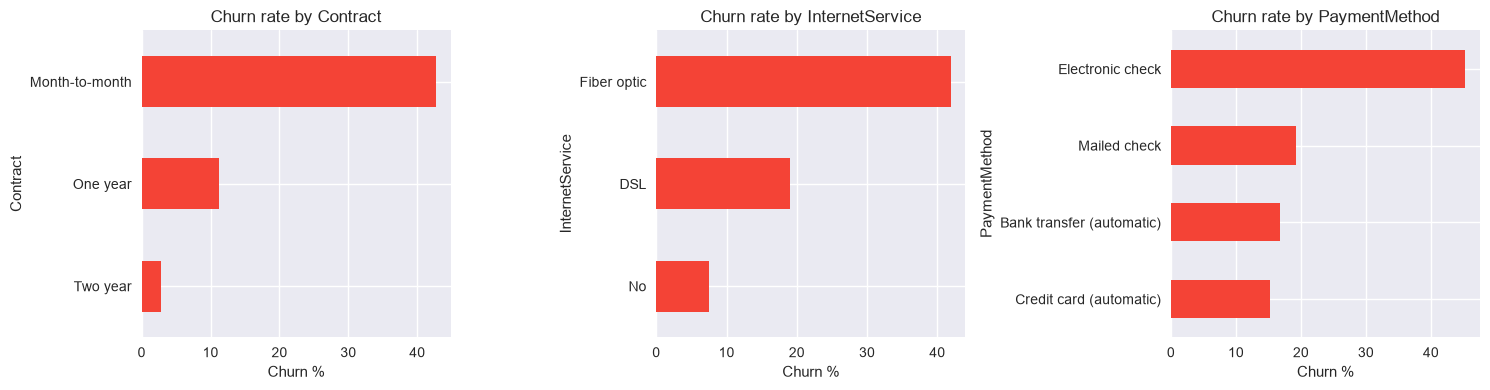

In [6]:
# Contract type vs churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Contract', 'InternetService', 'PaymentMethod']):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    churn_rate.sort_values().plot(kind='barh', ax=axes[i], color='#F44336')
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_xlabel('Churn %')

plt.tight_layout()
plt.savefig('../data/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

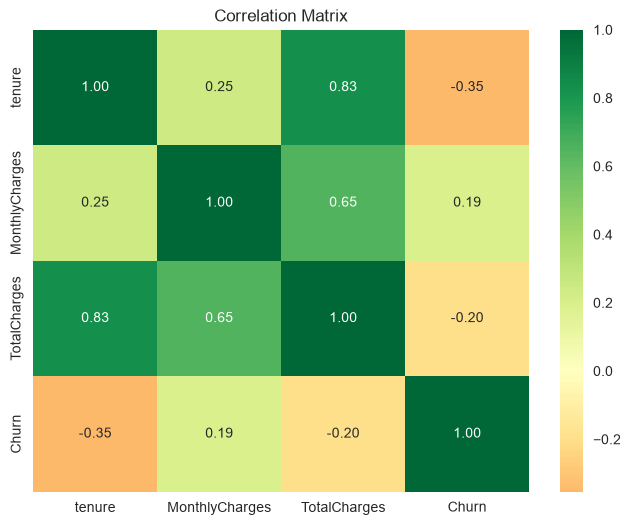

In [7]:
# Correlation heatmap
df_encoded = df.copy()
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)
corr = df_encoded[['tenure','MonthlyCharges','TotalCharges','Churn']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Matrix')
plt.savefig('../data/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings
- Churn rate is ~26% — imbalanced dataset
- Month-to-month contracts churn most
- Higher monthly charges correlate with churn
- Longer tenure = lower churn probability
- Fiber optic internet has highest churn rate